In [3]:
from modules.strategies import Base_RSI
from backtesting_engine.backtest_engine import BacktestEngine
from modules.data import generate_historical_data
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import pandas as pd

import cProfile
import pstats
import random

In [4]:
strategy_configs = {
    'RSI': {
        'stream_key': 'alpaca',
        'tickers': ['AAPL','AMD','CSCO','GOOG','INTC','JNPR','META','MSFT','NFLX','NVDA','TSLA'],  # List of tickers to trade
        'period': 14,  # Historical data required per new price entry
        'overbought_th': {'entry': 55, 'exit':50},  # Overbought threshold for RSI
        'oversold_th': {'entry': 45, 'exit':50},  # Oversold threshold for RSI
        'plot':False,
    },
}

strategy_name = 'RSI'

In [5]:
#tickers =  strategy_configs[strategy_name]['tickers'][0:3]
#start_time = datetime.now() - timedelta(days=1)  
#end_time = datetime.now()
#historical_data = generate_historical_data(tickers, start_time, end_time)
#historical_data.sort_values(by='timestamp', inplace=True)
#historical_data = historical_data.iloc[:15]
#historical_data.sample(frac=1).to_pickle('backtesting_engine/histdata_1D_3T_SHFL.pkl')
historical_data = pd.read_pickle('backtesting_engine/histdata_1D_3T_SHFL.pkl')
historical_data.head()

,timestamp,ticker,open,high,low,close
2020,2025-03-30 10:51:10.364650,AMD,251.56,251.99,249.07,250.54
2410,2025-03-30 17:21:10.364650,AMD,447.76,452.54,443.87,452.03
3121,2025-03-30 05:11:10.364650,CSCO,71.06,74.50,66.57,68.21
365,2025-03-30 07:17:10.364650,AAPL,326.71,327.92,319.75,324.07
1252,2025-03-30 22:04:10.364650,AAPL,173.95,174.33,168.26,169.58


In [7]:
%%time
profiler = cProfile.Profile()
profiler.enable()
strategy = Base_RSI(strategy_configs[strategy_name], mode='backtest')
backtest = BacktestEngine(strategy, historical_data)
backtest.run_backtest()
profiler.disable()

stats = pstats.Stats(profiler)
stats.strip_dirs().sort_stats("cumulative").print_stats(20)  # Show top 20 slowest calls

Positions initialized: {'AAPL': None, 'AMD': None, 'CSCO': None, 'GOOG': None, 'INTC': None, 'JNPR': None, 'META': None, 'MSFT': None, 'NFLX': None, 'NVDA': None, 'TSLA': None}
         1944795 function calls (1923124 primitive calls) in 3.238 seconds

   Ordered by: cumulative time
   List reduced from 585 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.068    0.068    2.957    2.957 backtest_engine.py:57(run_backtest)
     1441    0.033    0.000    2.799    0.002 frame.py:1559(itertuples)
1448/1446    0.009    0.000    2.023    0.001 {method 'extend' of 'list' objects}
    11528    0.026    0.000    2.015    0.000 frame.py:1630(<genexpr>)
    10087    0.088    0.000    1.905    0.000 indexing.py:1176(__getitem__)
    10087    0.060    0.000    1.575    0.000 indexing.py:1689(_getitem_tuple)
    10087    0.111    0.000    1.130    0.000 indexing.py:1032(_getitem_lowerdim)
    10087    0.063    0.000    0.853    0.00

In [9]:
%%time
profiler_t = cProfile.Profile()
profiler_t.enable()
strategy_t = Base_RSI(strategy_configs[strategy_name], mode='backtest')
backtest_t = BacktestEngine(strategy_t, historical_data)
backtest_t.run_backtest_t()
profiler_t.disable()

stats_t = pstats.Stats(profiler_t)
stats_t.strip_dirs().sort_stats("cumulative").print_stats(20)  # Show top 20 slowest calls

Positions initialized: {'AAPL': None, 'AMD': None, 'CSCO': None, 'GOOG': None, 'INTC': None, 'JNPR': None, 'META': None, 'MSFT': None, 'NFLX': None, 'NVDA': None, 'TSLA': None}
         1946842 function calls (1925174 primitive calls) in 3.081 seconds

   Ordered by: cumulative time
   List reduced from 604 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.066    0.066    3.082    3.082 backtest_engine.py:81(run_backtest_t)
     1441    0.035    0.000    2.729    0.002 frame.py:1559(itertuples)
     1448    0.009    0.000    2.025    0.001 {method 'extend' of 'list' objects}
    11528    0.027    0.000    2.016    0.000 frame.py:1630(<genexpr>)
    10087    0.088    0.000    1.978    0.000 indexing.py:1176(__getitem__)
    10087    0.058    0.000    1.628    0.000 indexing.py:1689(_getitem_tuple)
    10087    0.111    0.000    1.178    0.000 indexing.py:1032(_getitem_lowerdim)
    10087    0.064    0.000    0.896    0.

In [10]:
backtest.balance_hist == backtest_t.balance_hist

False

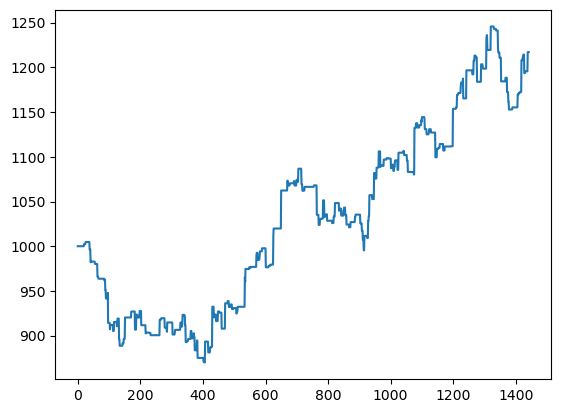

In [11]:
plt.plot(backtest.balance_hist)

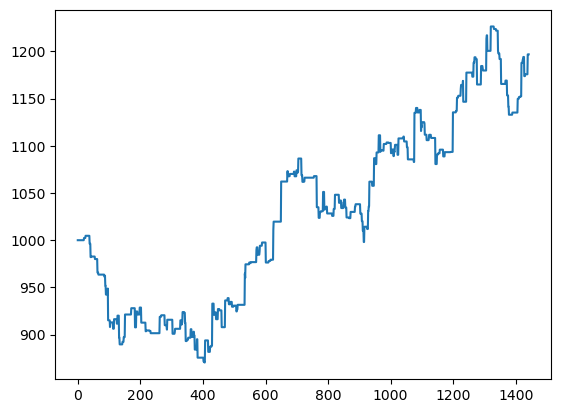

In [12]:
plt.plot(backtest_t.balance_hist)

In [9]:
len(backtest.balance_hist)

1442